Chemical Industry decarbonization with SMR-CHP 
(Economic analysis using PyPSA opensource toolbox)
# Scenario 1: simulation for 2035
Hypothesis: 
- Demand data from MECs (3% scaled down to spain case;  check calculus [file](https://docs.google.com/spreadsheets/d/1pLw4c-ZX__JsrjUIHaK1mmeCst81JXG1elViPpqSP6U/edit?gid=889823888#gid=889823888))
- Interest Rate Nominal conservative = 8% ([NREL](https://atb.nrel.gov/electricity/2024/data) ATB data)
- SMR costs from [NREL](https://atb.nrel.gov/electricity/2024/data). 
- GAS-CHP costs from PyPSA or [NREL](https://atb.nrel.gov/electricity/2024/data). 


The code is based in: 
- [basic example](https://pypsa.readthedocs.io/en/latest/examples/chp-fixed-heat-power-ratio.html), [Biomass example](https://pypsa.readthedocs.io/en/latest/examples/biomass-synthetic-fuels-carbon-management.html), and [variable heat-power example](https://pypsa.readthedocs.io/en/latest/examples/power-to-gas-boiler-chp.html)
- Previous work developed by Antonio Vaya and Daniel Juiz

In [52]:
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
import packages
# conda install openpyxl
# plt.style.use("bmh")


## 1. Costs input (2023)
Units from cost_final2024.xml
  - Investment (Overnight capital cost): USD/kWe
  - FOM: USD/kW/year
  - VOM: USD/MWh
  - Fuel: USD/MWh
  - Lifetime: years
  - Carbon_cost: USD/ton
  - carbon_intensity: gCO2/kWh
  - Capacity: MW (Net Capacity Factor: NREL)
  - Constrution time: years
  - load_factor: Unitarized
  - Tax: Unitarized
  - Rate: Unitarized 

In [53]:
#This line comented can be used to updated the costs from a cost_final24.xlsx Excel file

# #read from an excel file which is converted to csv
# cost=pd.read_excel('./cost_final24.xlsx')
# # Specify the output CSV file path
# csv_file11 = "./cost_final24.csv"
# # Save the DataFrame as a CSV file
# cost.to_csv(csv_file11, index=False)

# # #Costs updated, cost.final24.csv in directory, saved in the cost Data Frame

cost=pd.read_csv('./cost_final24.csv', index_col=0)

### Calculate LCOE for each tech

In [54]:
# Compute all LCOEs
df = pd.DataFrame()
techs=['SMR_CHP', 'Gas_CHP']

for tech in techs:
    df=pd.concat([df, packages.LCOE(tech, cost, tech)])

df

,investment,FOM,VOM,fuel,carbon_cost,tax
technology,,,,,,
SMR_CHP,129.707152,26.513478,2.8,12.0,0.0,0.0
Gas_CHP,5.980300,2.770615,5.5,50.0,0.0,0.0


Add carbon costs, from the 2024 World Energy Outlook [website](https://www.iea.org/reports/world-energy-outlook-2024).

In [55]:
#Updated from 85 to 90 USD/tonCO2 by 2024 World Energy Outlook.
cost.loc["Gas_CHP", "carbon_cost"]=90.

### Add taxes to nuclear energy
Taken from PWC's report. [website](https://www.pwc.es/es/publicaciones/energia/assets/fiscalidad-parque-nuclear.pdf)

In [56]:
cost["tax"] = cost["tax"].astype(float)
#impact of taxes, 16.31 // Source PWC 
cost.loc["SMR_CHP", "tax"]=16.31

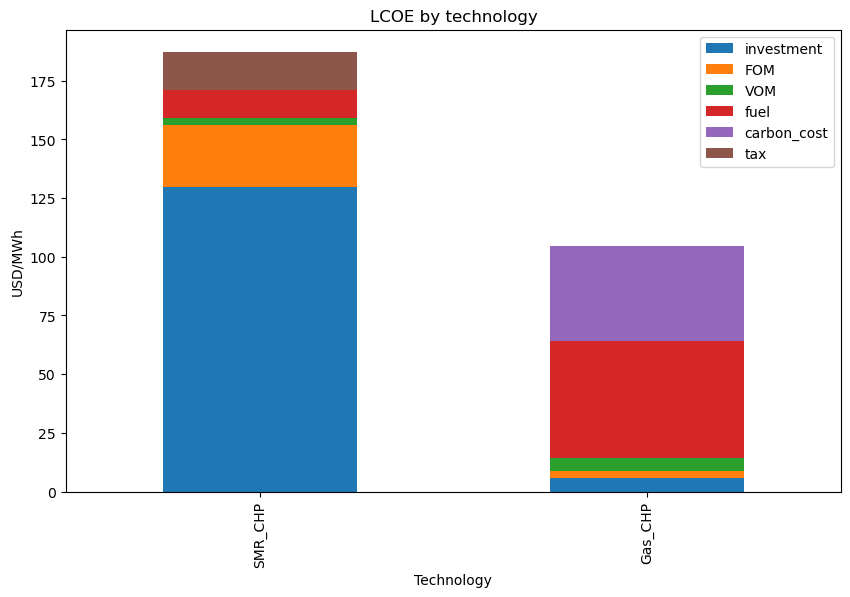

In [57]:
#Plot 
df3 = pd.DataFrame()
for tech in techs:
    df3=pd.concat([df3, packages.LCOE(tech, cost, tech)])

df3['Total'] = df3.sum(axis=1)
df3 = df3.sort_values(by='Total', ascending=False)
df3 = df3.drop(columns=['Total'])

df3.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Technology')
plt.ylabel('USD/MWh')
plt.title('LCOE by technology')
plt.show()

### Annualize investment values

In [58]:
#annualiazed investment costs
lifetime= cost["lifetime"].values

annualized_inv=[packages.annualized(val, cost.loc["SMR_CHP","rate"], lifetime[i])*1000 for i, val 
in enumerate(cost["investment"].values)] #USD/MW/y

#Add to dataframe cost
cost["annualized_investment"]=annualized_inv

### Add Carbon intensity values for techs that have CO2 emissions

In [59]:
#Adding carbon intensity in tCO2/MWh_th (from gCO2/kWh)
cost["carbon_intensity"] = cost["carbon_intensity"].astype(float)
cost.loc["Gas_CHP", "carbon_intensity"]=cost.loc["Gas_CHP", "carbon_intensity"]*0.5/1000
cost

,investment,FOM,VOM,lifetime,efficiency,construction_time,fuel,carbon_intensity,capacity,load_factor,rate,tax,carbon_cost,annualized_investment
technology,,,,,,,,,,,,,,
nuclear,6000.00,100.000000,2.000,60,0.000,7,9.33,0.000,1000,0.85,0.05,0.00,0,484787.692582
nuclear_lto,750.00,100.000000,4.000,10,0.000,2,9.33,0.000,1000,0.85,0.05,0.00,0,111772.116523
onwind,1160.00,25.000000,0.000,30,0.000,1,0.00,0.000,50,0.30,0.05,0.00,0,103039.822729
solar,671.00,18.200000,0.000,25,0.000,1,0.00,0.000,50,0.20,0.05,0.00,0,62858.460744
CCGT,750.00,20.167539,1.827,30,0.590,2,50.00,450.000,500,0.85,0.05,0.00,0,66620.575040
coal,1376.00,20.653000,5.250,40,0.450,4,30.00,850.000,500,0.85,0.05,0.00,0,115391.582225
battery,862.00,36.000000,0.000,15,0.000,1,0.00,0.000,100,0.50,0.05,0.00,0,100707.067735
hydro,2806.00,40.000000,0.000,60,0.000,6,0.00,0.000,500,0.20,0.05,0.00,0,226719.044231
ror,2318.00,50.000000,0.000,60,0.000,6,0.00,0.000,5,0.60,0.05,0.00,0,187289.645234


## 2. SMR vs Gas CHP + electric grid

### 2023 historical data: profiles, loads and prices
Source:  [ENTSOE Transparency Platform](https://newtransparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YES-REE------0%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%5B%222024%22%2C%222024%22%5D%2C%22tz%22%3A%22CET%22%7D)

In [60]:
CO2_reduction=0.5 # 50% CO2 emissions reduction for scenario 2035
# Using a carbon cost of: 90 USD/tonCO2 by 2024 World Energy Outlook --> cost.loc["Gas_CHP", "carbon_cost"]=90.
extra_cost=100000

## Configuración: True para pruebas rápidas, False para simulación completa
quick_test = True

if quick_test:
    snapshots = list(np.arange(1, 101, 1, dtype=int))  # Solo las primeras 100 horas
else:
    snapshots = list(np.arange(1, 8761, 1, dtype=int))  # Todas las 8760 horas

# Filtrar los datos según el rango de snapshots
profiles = pd.read_csv('./allprofiles_ES_2023.csv').iloc[:len(snapshots)]
loadES = pd.read_csv('./load_ES_2023.csv').iloc[:len(snapshots)]
PriceES = pd.read_csv('./ES_Price.csv').iloc[:len(snapshots)]

assert len(profiles) == len(snapshots), "El número de filas en profiles no coincide con los snapshots"
assert len(loadES) == len(snapshots), "El número de filas en loadES no coincide con los snapshots"
assert len(PriceES) == len(snapshots), "El número de filas en PriceES no coincide con los snapshots"

In [61]:
network=pypsa.Network() # Creates empty PyPSA network object called network
#Each hour is going to be a snapshot to optimize (Historical data loaded, as ES prices, have 8760 inputs)
network.set_snapshots(snapshots)

# 0) define carriers (optional) and co2 constraint
network.add("Carrier", "Gas",
            co2_emissions=cost.loc["CCGT","carbon_intensity"]) 
network.add("Carrier", "nuclear")
network.add("Carrier", "heat")
network.add("Carrier","electricity")

# 0.1) Define emissions constraint
CO2_avoided=cost.loc["Gas_CHP", "carbon_intensity"]*2.92E+06 # 2.92E+06 fuel avoided in MWh/year (maximum avoided [MECS 2018] considering fuel as 100% natural gas) 
limit_CO2=CO2_avoided*CO2_reduction # 50% reduction of CO2 emissions in tCO2/year
network.add("GlobalConstraint", "co2_limit", sense="<=", constant=limit_CO2)

# 1) Main Buses & loads----------------------------------------------------------------
network.add("Bus", "Industry Electricity", carrier="electricity") 
network.add("Load", "Industry Electricity Load", bus="Industry Electricity", p_set=135)

network.add("Bus", "Industry Heat", carrier="heat")
network.add("Load", "Industry Heat Load", bus="Industry Heat", p_set=294) # 294

# 2)  Fuel buses ----------------------------------------------------------------------
network.add("Bus", "uranium_UO2", carrier="nuclear")                  
network.add("Bus", "Gas_Fuel_in", carrier="Gas")
network.add("Bus", "Spain_grid", carrier="electricity")

# STORES ------------------------------------------------------------------------------
network.add("Store", "Spain gas", bus="Gas_Fuel_in",
    e_initial=1e9, 
    # e_nom=0,    # set pre-existing e_nom=50?
    e_nom_extendable=True)

network.add("Store", "uranium", bus="uranium_UO2",
    e_initial=1e9, 
    # e_nom=0, # set pre-existing e_nom=0?
    e_nom_extendable=True)

network.add("Store", "Spain grid", bus="Spain_grid",
    e_initial=1e9, 
    # e_nom=100, # set pre-existing e_nom=0?
    e_nom_extendable=True)

# Dump components as inverted generators------------------------------------------------
network.add("Generator","Electricity_Market",
    bus="Industry Electricity",
    p_nom=0,
    p_nom_max=200,
    p_nom_extendable=True,
    marginal_cost= (10+extra_cost), # selling prices as income (USD/MWh)
    carrier="electricity", 
    efficiency=-1) # consumes energy from bus, instead of generating it

network.add("Generator","Heat_Dump",
    bus="Industry Heat",
    p_nom=0,
    p_nom_max=200,
    p_nom_extendable=True,
    marginal_cost= (extra_cost+100000), # low cost for dumping
    carrier="heat", 
    efficiency=-1) # consumes energy from bus, instead of generating it


# LINKS----------------------------------------------------------------------------------
network.add( "Link", "Link_Gas_CHP",               
    bus0="Gas_Fuel_in",
    bus1="Industry Electricity",
    bus2="Industry Heat",
    carrier="Gas",
    p_nom=100,            # fixed p_nom Gas installed
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["Gas_CHP","annualized_investment"]+cost.loc["Gas_CHP","FOM"]*1000,     # fixed period costs of extending p_nom by 1 MW
    marginal_cost=(extra_cost+cost.loc["Gas_CHP","VOM"]+cost.loc["Gas_CHP","fuel"]), 
    efficiency=0.4, 
    efficiency2=0.35,
)
network.add( "Link", "Link_SMR_CHP",
    bus0="uranium_UO2",
    bus1="Industry Electricity",
    bus2="Industry Heat", 
    carrier="nuclear",
    p_nom=300, # set p_nom=0 initial value?
    p_nom_extendable=True, # Optimizes de p_nom value
    capital_cost=cost.loc["SMR_CHP","annualized_investment"]+cost.loc["SMR_CHP","FOM"], #annualized USD
    marginal_cost=(extra_cost+cost.loc["SMR_CHP","VOM"]+cost.loc["SMR_CHP","fuel"]),
    efficiency=0.45, 
    efficiency2=0.35,
)
network.add("Link", "Link_Spain_Grid",
    bus0="Spain_grid",
    bus1="Industry Electricity",
    carrier="electricity",
    p_nom=500, # connection capacity of 500 MW
    # p_nom_min=100,  # Optional: Minimum capacity
    p_nom_extendable=True,  #  Do not optimize capacity, it is fixed
    capital_cost=0,   # no fixed $/MW per period?
    marginal_cost=PriceES["Price"].values, # Spain energy prices for 2023
    efficiency=1)      #  electricity transport

Index(['Link_Spain_Grid'], dtype='object')

In [62]:
network.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1109 primals, 2411 duals
Objective: 6.65e+09
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## 3. Plot Results

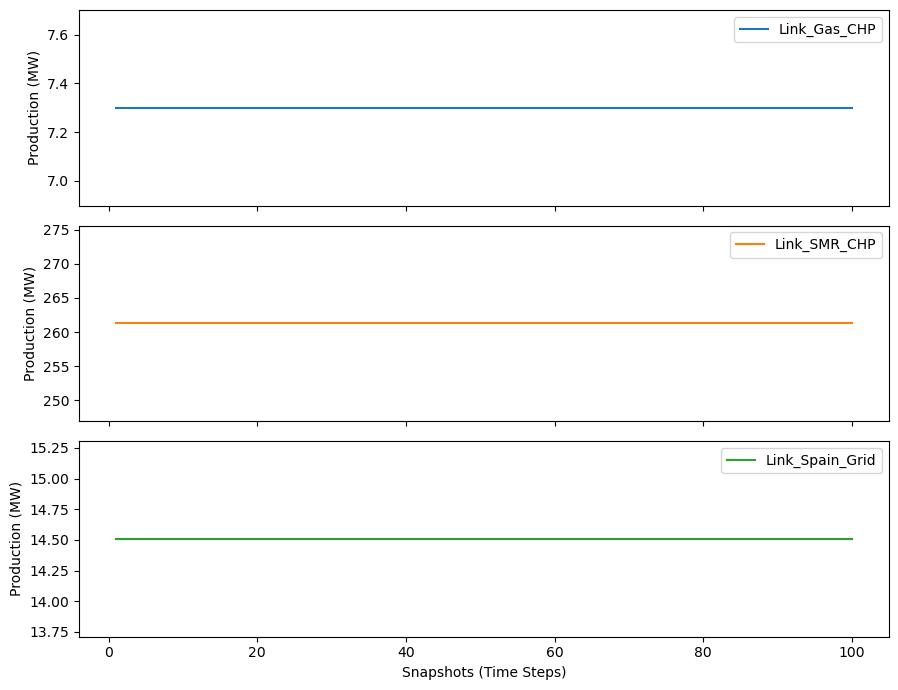

In [63]:
# Plot production view with subplots
ax = network.links_t.p0.plot(subplots=True, figsize=(9, 7))
# Add labels for x and y axes on each subplot
for subplot in ax:
    subplot.set_xlabel("Snapshots (Time Steps)")  # Label for x-axis
    subplot.set_ylabel("Production (MW)")         # Label for y-axis
# Adjust layout to prevent overlapping
plt.tight_layout()

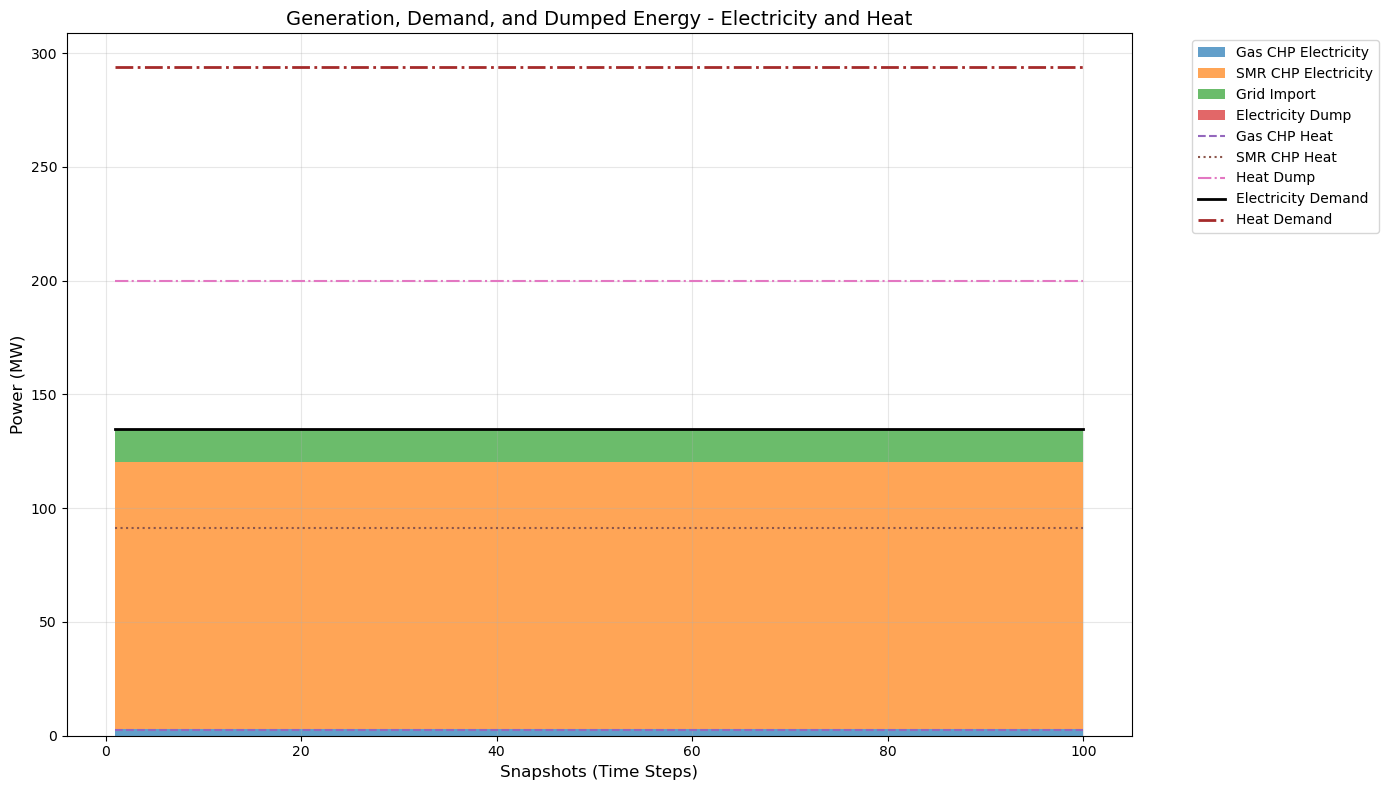

In [64]:
# Extract electricity generation data
generation = pd.concat([
    (-1) * network.links_t.p1["Link_Gas_CHP"],  # Gas_CHP electricity generation
    (-1) * network.links_t.p1["Link_SMR_CHP"],  # SMR_CHP electricity generation
    (-1) * network.links_t.p1["Link_Spain_Grid"],  # Grid electricity import
    network.generators_t.p["Electricity_Market"]  # Electricity dumped into the market
], axis=1)
generation.columns = ["Gas_CHP", "SMR_CHP", "Grid_Import", "Electricity_Dump"]

# Extract heat generation data
heat_generation = pd.concat([
    (-1) * network.links_t.p2["Link_Gas_CHP"],  # Gas_CHP heat generation
    (-1) * network.links_t.p2["Link_SMR_CHP"],  # SMR_CHP heat generation
    network.generators_t.p["Heat_Dump"]  # Heat dumped
], axis=1)
heat_generation.columns = ["Gas_CHP_Heat", "SMR_CHP_Heat", "Heat_Dump"]

# Combine data for plotting
combined = pd.concat([
    generation,
    heat_generation,
    network.loads_t.p["Industry Electricity Load"],  # Electricity demand
    network.loads_t.p["Industry Heat Load"]          # Heat demand
], axis=1)
combined.columns = [
    "Gas_CHP_Elec", "SMR_CHP_Elec", "Grid_Import", "Electricity_Dump",
    "Gas_CHP_Heat", "SMR_CHP_Heat", "Heat_Dump",
    "Elec_Demand", "Heat_Demand"
]
# Plot results
plt.figure(figsize=(14, 8))
# combined = combined.loc[100:200]  # Visualizar 100 horas

# Plot electricity generation as a stacked area chart
plt.stackplot(combined.index,
              combined["Gas_CHP_Elec"],
              combined["SMR_CHP_Elec"],
              combined["Grid_Import"],
              combined["Electricity_Dump"],
              labels=["Gas CHP Electricity", "SMR CHP Electricity", "Grid Import", "Electricity Dump"],
              colors=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
              alpha=0.7)

# Plot heat generation as lines
plt.plot(combined.index, combined["Gas_CHP_Heat"],
         label="Gas CHP Heat", linestyle="--", color="#9467bd")
plt.plot(combined.index, combined["SMR_CHP_Heat"],
         label="SMR CHP Heat", linestyle=":", color="#8c564b")
plt.plot(combined.index, combined["Heat_Dump"],
         label="Heat Dump", linestyle="-.", color="#e377c2")

# Plot demand as lines
plt.plot(combined.index, combined["Elec_Demand"],
         label="Electricity Demand", color="black", linewidth=2)
plt.plot(combined.index, combined["Heat_Demand"],
         label="Heat Demand", color="brown", linewidth=2, linestyle="-.")

# Configure plot
plt.title("Generation, Demand, and Dumped Energy - Electricity and Heat", fontsize=14)
plt.xlabel("Snapshots (Time Steps)", fontsize=12)
plt.ylabel("Power (MW)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
print("SMR Electricity Output:", network.links_t.p1["Link_SMR_CHP"].sum() )  # -MW
print("SMR Heat Output:", network.links_t.p2["Link_SMR_CHP"].sum())         # -MW
print("SMR Uranium Fuel Consumption:", network.links_t.p0["Link_SMR_CHP"].sum())    #+ MW

print("Gas_CHP Electricity Output:", network.links_t.p1["Link_Gas_CHP"].sum())
print("Gas_CHP Gas Consumption:", network.links_t.p0["Link_Gas_CHP"].sum())

print("Grid electricity output:", network.links_t.p1["Link_Spain_Grid"].sum())
print("Grid electricity Consumption:", network.links_t.p0["Link_Spain_Grid"].sum())

SMR Electricity Output: -11757.2142841816
SMR Heat Output: -9144.499998807909
SMR Uranium Fuel Consumption: 26127.142853736874
Gas_CHP Electricity Output: -292.00000136239294
Gas_CHP Gas Consumption: 730.0000034059825
Grid electricity output: -1450.7857144560123
Grid electricity Consumption: 1450.7857144560123


Note that negative values for network.links_t.p1 indicate that the link is injecting power into bus1 (This aligns with PyPSA's [convention](https://pypsa.readthedocs.io/en/latest/user-guide/design.html#sign-conventions) where power injected into a bus is considered negative, while power withdrawn from a bus is positive). 

- network.links_t.p0 # energy flows through the input bus (bus0) in each link (for each snapshot) CONSUMO DE COMBUSTIBLE
- network.links_t.p1 # energy flows through the output bus1 (bus1) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)
- network.links_t.p2 # energy flows through the output bus2 (bus2) in each link (for each snapshot) ENERGY GENERATION (CONVERSION)